# Q4 Ceiling-Aware Selected-Head Analysis

This notebook tests one focused idea: use annotation ceilings to select a single UdonPred head per target dataset, instead of averaging heads. It reuses existing test and validation prediction folders.


## 1. Setup


In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torchmetrics.functional import auroc, average_precision, spearman_corrcoef

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

UDONPRED_DIR = ROOT / "UdonPred"
RESULTS = ROOT / "results"
TEST_PREDICTION_ROOT = RESULTS / "udonpred_matrix" / "predictions"
VALID_PREDICTION_ROOT = RESULTS / "udonpred_validation_matrix" / "predictions"
ENSEMBLE_DIR = RESULTS / "ensembles_ceiling_selected_head"
ENSEMBLE_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ["trizod", "chezod", "softdis", "pdbflex", "atlas", "plddt", "disprot"]
NEGATED_DATASETS = {"chezod", "plddt"}
MASK_VALUE = 999.0
METRIC_COLS = [
    "trizod",
    "chezod",
    "softdis",
    "pdbflex",
    "atlas",
    "plddt",
    "disprot\n(AP)",
    "disprot\n(AUROC)",
]

pd.set_option("display.max_columns", 20)
sns.set_theme(style="whitegrid")


## 2. Load Predictions


In [2]:
def read_jsonl_records(path: Path) -> dict[str, dict[str, object]]:
    records = {}
    with path.open() as handle:
        for line in handle:
            raw = json.loads(line)
            records[str(raw["id"])] = {
                "sequence": str(raw["x_0"]),
                "labels": np.asarray(raw["y"], dtype=np.float64),
            }
    return records


def normalize_prediction_id(protein_id: str) -> str:
    protein_id = protein_id.strip().lstrip(">")
    if len(protein_id) >= 6 and protein_id.isdigit():
        base_len = len(protein_id) - 3
        return protein_id[:base_len] + "_" + "_".join(protein_id[base_len:])
    return protein_id


def read_caid_dir(input_dir: Path) -> dict[str, np.ndarray]:
    predictions = {}
    for path in sorted(input_dir.glob("*.caid")):
        with path.open() as handle:
            lines = handle.readlines()
        if not lines:
            raise ValueError(f"Empty prediction file: {path}")
        protein_id = normalize_prediction_id(lines[0])
        scores = []
        for line in lines[1:]:
            line = line.strip()
            if line:
                scores.append(float(line.split("\t")[2]))
        predictions[protein_id] = np.asarray(scores, dtype=np.float64)
    return predictions


def labels_in_disorder_direction(labels: np.ndarray, dataset: str) -> np.ndarray:
    return -labels if dataset in NEGATED_DATASETS else labels


def preds_in_disorder_direction(preds: np.ndarray, train_dataset: str) -> np.ndarray:
    return -preds if train_dataset in NEGATED_DATASETS else preds


def metric_columns_for_dataset(dataset: str) -> list[str]:
    return ["disprot\n(AP)", "disprot\n(AUROC)"] if dataset == "disprot" else [dataset]


def evaluate_vector(labels: np.ndarray, preds: np.ndarray, dataset: str) -> dict[str, float]:
    if len(labels) == 0:
        return {column: math.nan for column in metric_columns_for_dataset(dataset)}
    labels_tensor = torch.tensor(labels, dtype=torch.float32)
    preds_tensor = torch.tensor(preds, dtype=torch.float32)
    if dataset == "disprot":
        binary_labels = labels_tensor.to(torch.int)
        return {
            "disprot\n(AP)": float(average_precision(preds_tensor, binary_labels, task="binary")),
            "disprot\n(AUROC)": float(auroc(preds_tensor, binary_labels, task="binary")),
        }
    if np.unique(labels).size < 2 or np.unique(preds).size < 2:
        return {dataset: math.nan}
    return {dataset: float(spearman_corrcoef(preds_tensor, labels_tensor))}


def primary_metric(dataset: str) -> str:
    return "disprot\n(AP)" if dataset == "disprot" else dataset


def load_aligned_stack(split: str, prediction_root: Path, target_dataset: str) -> dict[str, object]:
    records = read_jsonl_records(UDONPRED_DIR / "data" / target_dataset / f"{split}.jsonl")
    pred_maps = {
        train_dataset: read_caid_dir(prediction_root / f"{train_dataset}_{target_dataset}")
        for train_dataset in DATASETS
    }

    label_chunks = []
    pred_chunks_by_train = {train_dataset: [] for train_dataset in DATASETS}
    residue_count = 0
    protein_count = 0
    for protein_id, record in records.items():
        labels = np.asarray(record["labels"], dtype=np.float64)
        mask = np.isfinite(labels) & (labels != MASK_VALUE)
        if not np.any(mask):
            continue

        for train_dataset, pred_map in pred_maps.items():
            if protein_id not in pred_map:
                raise ValueError(f"Missing prediction for {protein_id} in {train_dataset}_{target_dataset}")
            preds = pred_map[protein_id]
            if len(preds) != len(labels):
                raise ValueError(
                    f"{train_dataset}_{target_dataset}/{protein_id}: prediction length {len(preds)} "
                    f"!= label length {len(labels)}"
                )
            pred_chunks_by_train[train_dataset].append(preds_in_disorder_direction(preds, train_dataset)[mask])

        label_chunks.append(labels_in_disorder_direction(labels, target_dataset)[mask])
        residue_count += int(mask.sum())
        protein_count += 1

    y = np.concatenate(label_chunks)
    x = np.column_stack([np.concatenate(pred_chunks_by_train[train_dataset]) for train_dataset in DATASETS])
    return {
        "dataset": target_dataset,
        "split": split,
        "X": x,
        "y": y,
        "n_residues": residue_count,
        "n_proteins": protein_count,
    }


def load_split_stacks(split: str, prediction_root: Path) -> dict[str, dict[str, object]]:
    return {
        target_dataset: load_aligned_stack(split, prediction_root, target_dataset)
        for target_dataset in DATASETS
    }


test_stacks = load_split_stacks("test", TEST_PREDICTION_ROOT)
valid_stacks = load_split_stacks("valid", VALID_PREDICTION_ROOT)

alignment_summary = pd.DataFrame(
    [
        {"split": split, "dataset": dataset, "n_proteins": stack["n_proteins"], "n_residues": stack["n_residues"]}
        for split, stacks in [("test", test_stacks), ("valid", valid_stacks)]
        for dataset, stack in stacks.items()
    ]
)
display(alignment_summary)


,split,dataset,n_proteins,n_residues
0,test,trizod,348,37133
1,test,chezod,117,13068
2,test,softdis,1869,271668
3,test,pdbflex,1319,225651
4,test,atlas,140,16907
5,test,plddt,265,62945
6,test,disprot,319,99239
7,valid,trizod,685,77160
8,valid,chezod,117,13334
9,valid,softdis,1484,424887


## 3. Ceiling-Aware Selection


In [3]:
def score_individual_heads(stacks: dict[str, dict[str, object]]) -> pd.DataFrame:
    rows = []
    for train_index, train_dataset in enumerate(DATASETS):
        row = {"train_dataset": train_dataset}
        for target_dataset, stack in stacks.items():
            row.update(evaluate_vector(stack["y"], stack["X"][:, train_index], target_dataset))
        rows.append(row)
    return pd.DataFrame(rows).set_index("train_dataset")[METRIC_COLS]


def load_best_simple_baseline_scores() -> pd.Series:
    path = RESULTS / "normalized_headroom" / "best_simple_baseline_per_metric.csv"
    if path.exists():
        summary = pd.read_csv(path)
        return summary.set_index("test_metric")["best_simple_baseline_score"].reindex(METRIC_COLS).apply(pd.to_numeric, errors="coerce")

    baseline_matrix = pd.read_csv(RESULTS / "simple_baselines" / "matrix.csv")
    baseline_scores = baseline_matrix.set_index(["baseline", "train_dataset"])[METRIC_COLS]
    return baseline_scores.apply(pd.to_numeric, errors="coerce").max(axis=0)


def load_ceiling_matrix() -> pd.DataFrame:
    path = RESULTS / "normalized_headroom" / "ceiling_matrix.csv"
    if not path.exists():
        raise FileNotFoundError("Run scripts/compute_normalized_headroom.py first.")
    return pd.read_csv(path, index_col=0).reindex(index=DATASETS, columns=METRIC_COLS).apply(pd.to_numeric, errors="coerce")


def ceiling_adjusted_scores_for_target(target_dataset: str) -> pd.Series:
    metric = primary_metric(target_dataset)
    validation_scores = valid_individual[metric].reindex(DATASETS).astype(float)
    baseline_score = float(best_simple_baseline_scores[metric])
    validation_headroom = (validation_scores - baseline_score).clip(lower=0.0).fillna(0.0)

    ceiling_signal = ceiling_matrix[metric].reindex(DATASETS).astype(float)
    ceiling_signal = ceiling_signal.fillna(0.5).clip(lower=0.0)
    ceiling_signal.loc[target_dataset] = 1.0

    return validation_headroom * ceiling_signal


valid_individual = score_individual_heads(valid_stacks)
test_individual = score_individual_heads(test_stacks)
best_individual_scores = test_individual.max(axis=0)
best_individual_heads = test_individual.idxmax(axis=0)
best_simple_baseline_scores = load_best_simple_baseline_scores()
ceiling_matrix = load_ceiling_matrix()

validation_selected_head_by_target = {
    dataset: valid_individual[primary_metric(dataset)].idxmax()
    for dataset in DATASETS
}

ceiling_selected_adjusted_scores = pd.DataFrame(
    {dataset: ceiling_adjusted_scores_for_target(dataset) for dataset in DATASETS}
).T.reindex(index=DATASETS, columns=DATASETS)

ceiling_selected_head_by_target = {
    dataset: ceiling_selected_adjusted_scores.loc[dataset].idxmax()
    for dataset in DATASETS
}

selection_table = pd.DataFrame(
    {
        "validation_selected_head": pd.Series(validation_selected_head_by_target),
        "ceiling_selected_head": pd.Series(ceiling_selected_head_by_target),
    }
)
selection_table["changed_by_ceiling"] = selection_table["validation_selected_head"] != selection_table["ceiling_selected_head"]

selection_table.to_csv(ENSEMBLE_DIR / "ceiling_selected_heads.csv")
ceiling_selected_adjusted_scores.to_csv(ENSEMBLE_DIR / "ceiling_selected_adjusted_scores.csv")
valid_individual.to_csv(ENSEMBLE_DIR / "validation_individual_matrix.csv")
test_individual.to_csv(ENSEMBLE_DIR / "test_individual_matrix.csv")

display(selection_table)
display(ceiling_selected_adjusted_scores.style.format("{:.3f}"))


,validation_selected_head,ceiling_selected_head,changed_by_ceiling
trizod,trizod,trizod,False
chezod,chezod,chezod,False
softdis,softdis,softdis,False
pdbflex,pdbflex,pdbflex,False
atlas,atlas,atlas,False
plddt,plddt,plddt,False
disprot,disprot,disprot,False


train_dataset,trizod,chezod,softdis,pdbflex,atlas,plddt,disprot
trizod,0.318,0.141,0.132,0.011,0.122,0.124,0.118
chezod,0.124,0.262,0.064,0.000,0.040,0.124,0.090
softdis,0.000,0.000,0.008,0.000,0.000,0.000,0.000
pdbflex,0.000,0.000,0.000,0.154,0.000,0.000,0.000
atlas,0.000,0.000,0.114,0.013,0.368,0.021,0.099
plddt,0.198,0.273,0.304,0.002,0.126,0.499,0.215
disprot,0.106,0.098,0.103,0.000,0.095,0.096,0.266


## 4. Evaluate Selected Heads


In [4]:
def predictions_for_selected_heads(selection: dict[str, str], target_dataset: str, stack: dict[str, object]) -> np.ndarray:
    selected_head = selection[target_dataset]
    return stack["X"][:, DATASETS.index(selected_head)]


strategies = {
    "best_individual_test_oracle": None,
    "validation_selected_single_head": validation_selected_head_by_target,
    "ceiling_aware_selected_single_head": ceiling_selected_head_by_target,
}

rows = []
for strategy, selection in strategies.items():
    row = {"strategy": strategy}
    if strategy == "best_individual_test_oracle":
        row.update(best_individual_scores.to_dict())
    else:
        for dataset, stack in test_stacks.items():
            preds = predictions_for_selected_heads(selection, dataset, stack)
            row.update(evaluate_vector(stack["y"], preds, dataset))
    rows.append(row)

selected_matrix = pd.DataFrame(rows).set_index("strategy")[METRIC_COLS]
selected_delta = selected_matrix.subtract(best_individual_scores, axis="columns")

available_headroom = 1.0 - best_simple_baseline_scores
raw_headroom = selected_matrix.subtract(best_simple_baseline_scores, axis="columns")
normalized_headroom = raw_headroom.divide(available_headroom, axis="columns")
normalized_headroom.loc[:, available_headroom <= 1e-12] = np.nan

summary_rows = []
for strategy in selected_matrix.index:
    summary_rows.append(
        {
            "strategy": strategy,
            "mean_score": float(selected_matrix.loc[strategy].mean()),
            "mean_normalized_headroom": float(normalized_headroom.loc[strategy].mean()),
            "wins_vs_best_individual": int((selected_delta.loc[strategy] > 1e-6).sum()),
            "ties_vs_best_individual": int((selected_delta.loc[strategy].abs() <= 1e-6).sum()),
            "losses_vs_best_individual": int((selected_delta.loc[strategy] < -1e-6).sum()),
        }
    )
selected_summary = pd.DataFrame(summary_rows).set_index("strategy")

selected_matrix.to_csv(ENSEMBLE_DIR / "selected_head_matrix.csv")
selected_delta.to_csv(ENSEMBLE_DIR / "selected_head_delta_vs_best_individual.csv")
normalized_headroom.to_csv(ENSEMBLE_DIR / "selected_head_normalized_headroom.csv")
selected_summary.to_csv(ENSEMBLE_DIR / "selected_head_summary.csv")

display(selected_matrix.style.format("{:.3f}"))
display(normalized_headroom.style.format("{:.3f}"))
display(selected_summary.style.format("{:.3f}"))


,trizod,chezod,softdis,pdbflex,atlas,plddt,disprot (AP),disprot (AUROC)
strategy,,,,,,,,
best_individual_test_oracle,0.508,0.708,0.500,0.395,0.708,0.839,0.935,0.959
validation_selected_single_head,0.508,0.691,0.500,0.395,0.708,0.839,0.935,0.959
ceiling_aware_selected_single_head,0.508,0.691,0.500,0.395,0.708,0.839,0.935,0.959


,trizod,chezod,softdis,pdbflex,atlas,plddt,disprot (AP),disprot (AUROC)
strategy,,,,,,,,
best_individual_test_oracle,0.322,0.369,0.314,0.248,0.580,0.760,0.820,0.832
validation_selected_single_head,0.322,0.334,0.314,0.248,0.580,0.760,0.820,0.832
ceiling_aware_selected_single_head,0.322,0.334,0.314,0.248,0.580,0.760,0.820,0.832


,mean_score,mean_normalized_headroom,wins_vs_best_individual,ties_vs_best_individual,losses_vs_best_individual
strategy,,,,,
best_individual_test_oracle,0.694,0.531,0.000,8.000,0.000
validation_selected_single_head,0.692,0.526,0.000,7.000,1.000
ceiling_aware_selected_single_head,0.692,0.526,0.000,7.000,1.000


## 5. Plots


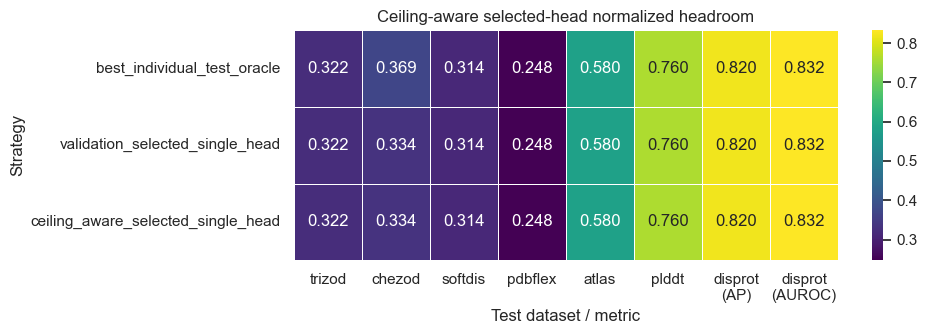

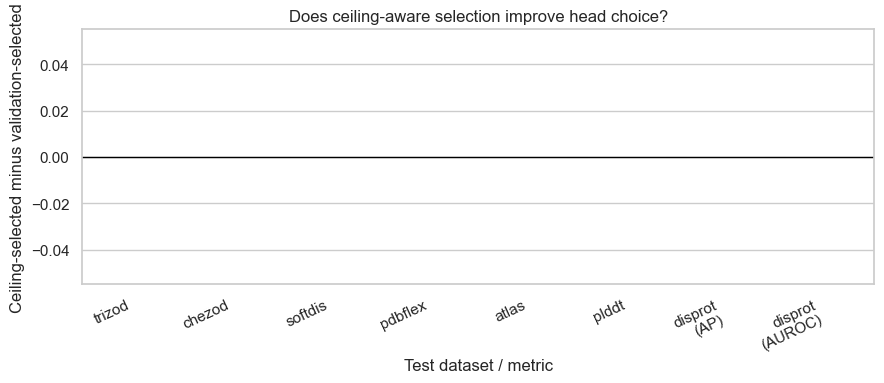

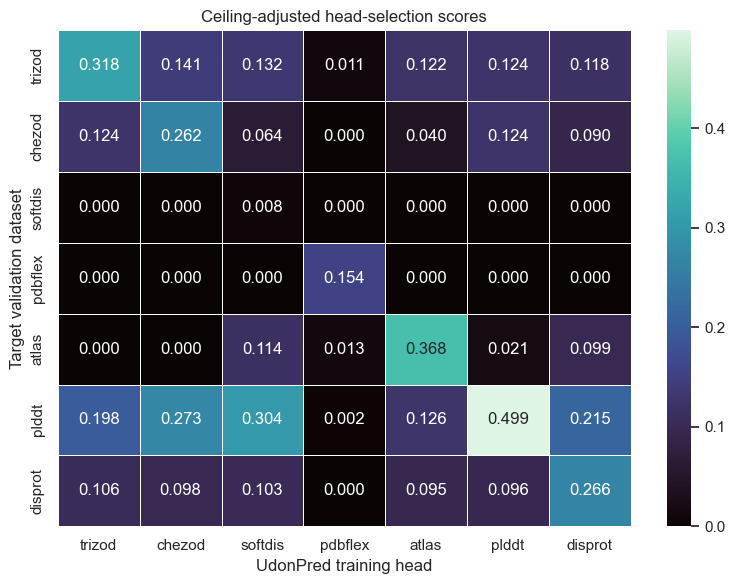

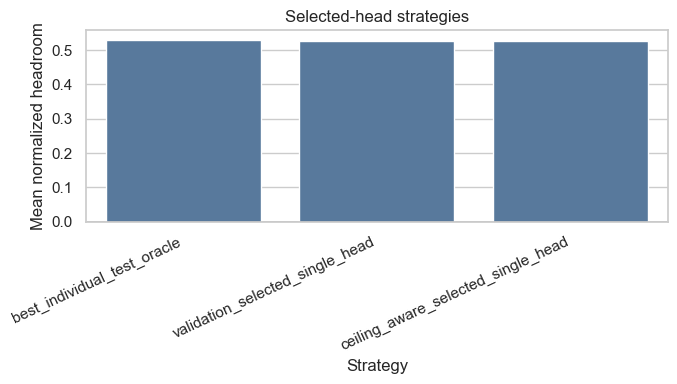

In [5]:
def save_heatmap(matrix: pd.DataFrame, path: Path, title: str, cmap: str = "viridis", center: float | None = None, fmt: str = ".3f") -> None:
    if matrix.empty or not matrix.notna().any().any():
        print(f"Skipping {path.name}: no finite values to plot.")
        return
    plt.figure(figsize=(10, max(3.5, 0.55 * len(matrix))))
    sns.heatmap(matrix, annot=True, fmt=fmt, cmap=cmap, center=center, linewidths=0.5, linecolor="white")
    plt.xlabel("Test dataset / metric")
    plt.ylabel("Strategy")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()


save_heatmap(
    normalized_headroom,
    ENSEMBLE_DIR / "ceiling_selected_normalized_headroom_heatmap.png",
    "Ceiling-aware selected-head normalized headroom",
)

selection_delta = (
    normalized_headroom.loc["ceiling_aware_selected_single_head"]
    - normalized_headroom.loc["validation_selected_single_head"]
).to_frame("delta_vs_validation_selected")
selection_delta["metric"] = selection_delta.index
plt.figure(figsize=(9, 4))
sns.barplot(data=selection_delta, x="metric", y="delta_vs_validation_selected", color="#54A24B")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=25, ha="right")
plt.xlabel("Test dataset / metric")
plt.ylabel("Ceiling-selected minus validation-selected")
plt.title("Does ceiling-aware selection improve head choice?")
plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "ceiling_selected_delta_vs_validation_selected.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(
    ceiling_selected_adjusted_scores,
    annot=True,
    fmt=".3f",
    cmap="mako",
    linewidths=0.5,
    linecolor="white",
)
plt.xlabel("UdonPred training head")
plt.ylabel("Target validation dataset")
plt.title("Ceiling-adjusted head-selection scores")
plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "ceiling_selected_adjusted_score_heatmap.png", dpi=200)
plt.show()

plot_summary = selected_summary.reset_index()
plt.figure(figsize=(7, 4))
sns.barplot(data=plot_summary, x="strategy", y="mean_normalized_headroom", color="#4C78A8")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=25, ha="right")
plt.xlabel("Strategy")
plt.ylabel("Mean normalized headroom")
plt.title("Selected-head strategies")
plt.tight_layout()
plt.savefig(ENSEMBLE_DIR / "ceiling_selected_mean_normalized_headroom.png", dpi=200)
plt.show()


## 6. Numerical Summary

The cell below prints the selected heads and the strategy-level score summary.


In [6]:
print("Ceiling-aware selected heads:")
for dataset, head in ceiling_selected_head_by_target.items():
    changed = "changed" if selection_table.loc[dataset, "changed_by_ceiling"] else "same as validation"
    print(f"- {dataset}: {head} ({changed})")

print()
print("Summary:")
display(selected_summary.style.format("{:.3f}"))


Ceiling-aware selected heads:
- trizod: trizod (same as validation)
- chezod: chezod (same as validation)
- softdis: softdis (same as validation)
- pdbflex: pdbflex (same as validation)
- atlas: atlas (same as validation)
- plddt: plddt (same as validation)
- disprot: disprot (same as validation)

Summary:


,mean_score,mean_normalized_headroom,wins_vs_best_individual,ties_vs_best_individual,losses_vs_best_individual
strategy,,,,,
best_individual_test_oracle,0.694,0.531,0.000,8.000,0.000
validation_selected_single_head,0.692,0.526,0.000,7.000,1.000
ceiling_aware_selected_single_head,0.692,0.526,0.000,7.000,1.000


## 7. Full Interpretation of the Ceiling-Aware Selected-Head Results

### What was tested

This notebook asks whether the annotation ceiling can be used to choose one UdonPred head per target dataset. The biological idea is reasonable: if a training dataset is known to agree strongly with a target dataset, its head might be a better choice than simply choosing the head that performs best on validation. The lecture slides motivate this because different disorder sources measure different biological concepts, and because method comparisons must use the same measure and the same dataset whenever possible.

### Main result

The ceiling-aware selection did not change any head. For every target dataset, the selected head remained the same-dataset head: TriZOD for TriZOD, CheZOD for CheZOD, SoftDis for SoftDis, PDBFlex for PDBFlex, Atlas for Atlas, pLDDT for pLDDT, and DisProt for DisProt. As a result, the ceiling-aware selected-head strategy and the validation-selected single-head strategy have identical test performance.

Numerically, the ceiling-aware and validation-selected strategies have mean score = 0.692 and mean normalized headroom = 0.526. The test-oracle best individual head has mean score = 0.694 and mean normalized headroom = 0.531. The selected strategies tie the oracle on seven of eight reported metrics and lose only on CheZOD, where the test oracle uses the TriZOD head and reaches 0.708 instead of 0.691. This difference is small in absolute terms but biologically interpretable.

### Biological interpretation

The fact that ceiling-aware selection keeps the same-dataset heads is not a failure of the analysis. It says that, once the annotation ceilings and validation scores are combined, the safest biological assumption is still that each model head is best aligned with the annotation definition on which it was trained. This is exactly what the lecture framing predicts: disorder labels are not interchangeable, so the most annotation-compatible head for a target is usually the head trained on the same annotation source.

For TriZOD and CheZOD, the same-head choice reflects the NMR chemical-shift nature of the targets. These datasets are closest to direct physical disorder measurements. Cross-transfer between them is plausible, but the annotation ceiling estimate for TriZOD vs CheZOD is only moderate and based on one overlapping protein. Therefore the ceiling-aware procedure correctly avoids treating that cross-source relationship as a strong enough reason to override the same-dataset head.

For pLDDT, the same-head choice is also biologically sensible. pLDDT converted to `1 - pLDDT / 100` behaves like a disorder proxy, and it agrees moderately to strongly with CheZOD and SoftDis in the ceiling analysis. Still, pLDDT is AlphaFold confidence, not experimental disorder. A pLDDT-trained head is therefore expected to be best at reproducing the confidence-derived target, while NMR or curated-disorder heads may capture related but not identical biology.

For DisProt, the same-head choice means the curated binary disorder concept remains distinct enough to warrant its own model. SoftDis has high AUROC agreement with DisProt in the overlap analysis, but DisProt labels are binary and curated from heterogeneous experimental evidence. The DisProt head preserves that target-specific decision boundary and gives the best selected result on both DisProt AP and AUROC.

For PDBFlex, the same-head choice is especially important biologically. The lecture slides warn that B-values and flexibility capture protein dynamics, not disorder directly. The ceiling analysis confirms this: PDBFlex has very low agreement with pLDDT, SoftDis, Atlas, and DisProt. A ceiling-aware selector should therefore not replace the PDBFlex head with a more general disorder head. PDBFlex is best treated as a flexibility target, not as a generic IDR target.

### Why the oracle only improves CheZOD

The test oracle chooses the best individual head after looking at test performance, so it is not a deployable selection rule. Its only improvement is on CheZOD, where TriZOD gives 0.708 compared with the selected CheZOD head at 0.691. Biologically this is plausible because TriZOD and CheZOD are both NMR chemical-shift-derived disorder resources, and TriZOD may provide a broader or better-normalized version of a similar signal. However, the ceiling estimate between TriZOD and CheZOD is based on only one overlapping protein, so the evidence is too weak to justify changing the selection rule globally. The conservative interpretation is that TriZOD may be a useful CheZOD-compatible head, but this needs more matched NMR overlap or validation evidence.

### Interpretation of normalized headroom

Normalized headroom asks how much of the performance available above a simple baseline is recovered before reaching the annotation ceiling. The selected-head strategy recovers substantial headroom for pLDDT and DisProt, moderate headroom for Atlas, and lower headroom for TriZOD, CheZOD, SoftDis, and PDBFlex. This pattern suggests that UdonPred captures strong target-specific signals for pLDDT confidence and curated DisProt disorder, but still leaves substantial unexplained biological or annotation variance for the continuous disorder/flexibility datasets.

The PDBFlex normalized headroom remains low even with the PDBFlex head. This fits the biological interpretation that flexibility is noisy and context-dependent: B-factor-like labels depend on crystal environment, local packing, protein motion, and experimental conditions. A sequence-only or embedding-based predictor can learn some flexibility tendencies, but the ceiling and headroom analysis both argue against treating PDBFlex as an easy or clean disorder target.

### Final conclusion

The ceiling-aware selected-head analysis supports a conservative biological conclusion: disorder predictors should be selected according to the annotation concept they are meant to reproduce. The analysis does not show that a different head can generally outperform the same-dataset head using ceiling information alone. Instead, it shows that the annotation ceiling is most useful as an interpretation tool: it explains why some transfers are biologically plausible, why PDBFlex should be separated from disorder labels, and why apparent cross-dataset gains must be judged against annotation compatibility rather than raw metric values alone.

